<a href="https://colab.research.google.com/github/bhuttazain/Operator-Scheduling-Problem/blob/main/Operator_Scheduling_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 — Heuristic Search Methods  
## Operator Scheduling Problem  
### Comparative Study using Genetic Algorithm and Tabu Search

---

## 1. Problem Statement

In this assignment, we consider the **operator scheduling problem** for a manufacturing plant. The goal is to determine a workforce schedule that **minimizes the total labor cost** while satisfying staffing requirements during both peak and non-peak production hours.

The plant employs:

- **full-time operators**, each with a different hourly wage,
- **part-time operators**, who are available only during non-peak hours at lower wage rates,
- and allows **overtime** for full-time operators during peak hours at a higher hourly rate.

The scheduling policy must ensure:

- at least **4 operators** are available during **peak hours**,
- at least **2 operators** are available during **non-peak hours**.

The objective is to find a feasible schedule with the **minimum possible total labor cost**.

---

## 2. Mathematical Formulation

### Objective Function

The operator scheduling problem is formulated as the minimization of total labor cost:

$$
f(x) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
$$

where:

- $c_i$ = hourly wage of full-time operator $i$
- $c_i^{o}$ = overtime hourly wage of full-time operator $i$
- $c_j^{p}$ = hourly wage of part-time operator $j$
- $x_i$ = regular working hours assigned to full-time operator $i$ during peak hours
- $x_i^{o}$ = overtime working hours assigned to full-time operator $i$ during peak hours
- $x_j^{p}$ = working hours assigned to part-time operator $j$ during non-peak hours

---

### Constraints

#### Peak-hour staffing requirement

At least 4 operators must be scheduled during peak hours:

$$
\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o} \geq 4
$$

#### Non-peak-hour staffing requirement

At least 2 operators must be scheduled during non-peak hours:

$$
\sum_{j=1}^{n} x_j^{p} \geq 2
$$

#### Non-negativity constraints

$$
x_i \geq 0, \quad x_i^{o} \geq 0, \quad x_j^{p} \geq 0
$$

---

## 3. Parameters

The wage rates provided in the assignment are as follows.

### Full-time operator hourly wages

$$
[30,\ 35,\ 40,\ 45,\ 50]
$$

### Overtime hourly wages

The overtime rate is 1.5 times the regular full-time wage:

$$
[45,\ 52.5,\ 60,\ 67.5,\ 75]
$$

### Part-time operator hourly wages

$$
[25,\ 27,\ 29,\ 31,\ 33]
$$

---

## 4. Decision Variables

Let:

- $x_i$ denote the number of regular working hours assigned to full-time operator $i$, for $i = 1,2,\dots,m$
- $x_i^{o}$ denote the number of overtime working hours assigned to full-time operator $i$, for $i = 1,2,\dots,m$
- $x_j^{p}$ denote the number of working hours assigned to part-time operator $j$, for $j = 1,2,\dots,n$

where:

- $m$ = number of full-time operators
- $n$ = number of part-time operators

---

## 5. Problem Type and Solution Approach

This is a **constrained cost-minimization scheduling problem**. Since the problem involves allocation decisions under staffing constraints, heuristic optimization methods are appropriate.

In this notebook, the problem will be solved using:

1. **Genetic Algorithm (GA)**
2. **Tabu Search (TS)**

These two methods will be compared in terms of solution quality, convergence behavior, and computational performance.

---

## 6. Modeling Note for Implementation

For implementation purposes, each candidate solution will represent the assigned values of:

- full-time regular hours,
- full-time overtime hours,
- and part-time working hours.

Constraint handling will be incorporated in the fitness evaluation using a penalty mechanism so that infeasible solutions are discouraged during the search process.

---

## 7. Solution Representation

To apply heuristic algorithms, each candidate solution must be encoded in a structured form.

A solution vector is defined as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

Thus, the solution vector contains:

- $m$ variables for regular full-time hours,
- $m$ variables for overtime,
- $n$ variables for part-time hours.

Each solution represents a **complete workforce schedule**.

---

## 8. Fitness Function Design

The goal is to minimize total labor cost. Therefore, the **fitness function** is defined based on the objective function.

### Cost Function

$$
\text{Cost}(X) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
$$

Since heuristic methods may generate infeasible solutions, a **penalty function** is introduced.

---

## 9. Constraint Handling

To ensure feasibility, violations of constraints are penalized.

### Peak-hour constraint violation

$$
V_{\text{peak}} = \max\left(0,\; 4 - \left(\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o}\right)\right)
$$

### Non-peak constraint violation

$$
V_{\text{non-peak}} = \max\left(0,\; 2 - \sum_{j=1}^{n} x_j^{p}\right)
$$

---

### Penalized Fitness Function

The final fitness function is defined as:

$$
F(X) = \text{Cost}(X) + \lambda_1 V_{\text{peak}} + \lambda_2 V_{\text{non-peak}}
$$

where:

- $\lambda_1, \lambda_2$ are large penalty coefficients.

This ensures that infeasible solutions receive higher cost values and are less likely to be selected.

---

## 10. Solution Feasibility Strategy

Two mechanisms are used:

1. **Penalty-based approach**  
   - Constraint violations increase the fitness value.
   - Encourages feasible solutions during evolution.

2. **Optional repair mechanism (used later)**  
   - Adjusts solutions to satisfy minimum staffing requirements.
   - Helps improve convergence speed.

---

## 11. Encoding Considerations

- All variables are **non-negative**.
- Values may be treated as:
  - continuous (then rounded), or
  - discrete integers (preferred for scheduling interpretation).

For this study, solutions will be treated as **integer-valued** for clarity and realism.

---

## 12. Summary of Modeling Choices

| Component | Design Choice |
|---|---|
| Representation | Vector of staffing allocations |
| Objective | Minimize total labor cost |
| Constraints | Handled via penalty function |
| Variables | Integer, non-negative |
| Feasibility | Penalty + optional repair |

---


## 13. Genetic Algorithm Implementation Using PyMOO

The first heuristic method used in this study is the **Genetic Algorithm (GA)**. In this notebook, GA is implemented using the **PyMOO** library, which provides a structured framework for evolutionary optimization.

GA is suitable for the operator scheduling problem because it explores a population of candidate staffing schedules and improves them iteratively through crossover and mutation.

To improve search quality, a **multi-stage adaptive GA strategy** is used. Instead of keeping the same parameters throughout the entire run, the GA is executed in three phases:

1. **Exploration phase**: high mutation and strong crossover for global search  
2. **Balanced phase**: moderate mutation for mixed exploration and exploitation  
3. **Exploitation phase**: low mutation for local refinement  

This adaptive strategy helps the algorithm converge more reliably to high-quality solutions.

### 13.1 Chromosome Representation

Each candidate solution is represented as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

For this problem:

- the first 5 variables represent regular full-time allocations,
- the next 5 variables represent overtime allocations,
- the last 5 variables represent part-time allocations.

Thus, each solution vector contains 15 decision variables.

### 13.2 Feasibility and Cost-Aware Normalization

In the initial GA version, infeasible or unnecessarily expensive schedules could remain in the population. To improve performance, a **cost-aware normalization step** is used.

This normalization performs the following:

- ensures that peak-hour staffing satisfies the minimum requirement,
- ensures that non-peak-hour staffing satisfies the minimum requirement,
- removes unnecessary excess allocation,
- prioritizes cheaper allocations before more expensive ones.

This makes the search more stable and helps the GA converge toward lower-cost feasible schedules.

In [9]:
#!pip install pymoo -q

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.pntx import SinglePointCrossover
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize

In [51]:
# Problem data from the assignment
full_time_rates = np.array([30, 35, 40, 45, 50], dtype=float)
overtime_rates = 1.5 * full_time_rates
part_time_rates = np.array([25, 27, 29, 31, 33], dtype=float)

m = len(full_time_rates)   # number of full-time operators
n = len(part_time_rates)   # number of part-time operators

# Total number of decision variables:
# [x1..x5, xo1..xo5, xp1..xp5]
n_var = m + m + n

# Integer bounds for each variable
xl = np.zeros(n_var, dtype=int)
xu = np.full(n_var, 8, dtype=int)

def decode_solution(x):
    x = np.array(x, dtype=int)
    regular = x[:m]
    overtime = x[m:2*m]
    part_time = x[2*m:]
    return regular, overtime, part_time


def compute_cost(x):
    regular, overtime, part_time = decode_solution(x)
    return float(
        np.sum(full_time_rates * regular) +
        np.sum(overtime_rates * overtime) +
        np.sum(part_time_rates * part_time)
    )


def is_feasible(x):
    regular, overtime, part_time = decode_solution(x)
    peak_coverage = np.sum(regular) + np.sum(overtime)
    nonpeak_coverage = np.sum(part_time)
    return (peak_coverage >= 4) and (nonpeak_coverage >= 2)

def normalize_solution(x):
    """
    Convert any candidate solution into a low-cost feasible schedule.

    Strategy:
    1. Clip values to valid integer bounds
    2. Enforce peak coverage >= 4 using the cheapest peak allocations
    3. Enforce non-peak coverage >= 2 using the cheapest part-time allocations
    4. Remove unnecessary excess allocation from the most expensive variables first
    """
    x = np.array(np.rint(x), dtype=int)
    x = np.clip(x, xl, xu)

    regular, overtime, part_time = decode_solution(x)

    # -----------------------------
    # Peak side: regular + overtime
    # -----------------------------
    peak = np.concatenate([regular, overtime])
    peak_costs = np.concatenate([full_time_rates, overtime_rates])

    # If peak coverage is too small, add missing units to the cheapest peak variables
    peak_total = np.sum(peak)
    if peak_total < 4:
        deficit = 4 - peak_total
        cheapest_peak_idx = np.argsort(peak_costs)   # ascending cost
        for idx in cheapest_peak_idx:
            add = min(deficit, xu[idx] - peak[idx])
            peak[idx] += add
            deficit -= add
            if deficit == 0:
                break

    # If peak coverage is too large, remove excess from the most expensive peak variables
    peak_total = np.sum(peak)
    if peak_total > 4:
        excess = peak_total - 4
        expensive_peak_idx = np.argsort(-peak_costs)  # descending cost
        for idx in expensive_peak_idx:
            remove = min(excess, peak[idx])
            peak[idx] -= remove
            excess -= remove
            if excess == 0:
                break

    regular = peak[:m]
    overtime = peak[m:]

    # -----------------------------
    # Non-peak side: part-time only
    # -----------------------------
    nonpeak_total = np.sum(part_time)

    # If non-peak coverage is too small, add missing units to the cheapest part-time variables
    if nonpeak_total < 2:
        deficit = 2 - nonpeak_total
        cheapest_pt_idx = np.argsort(part_time_rates)
        for idx in cheapest_pt_idx:
            add = min(deficit, xu[2*m + idx] - part_time[idx])
            part_time[idx] += add
            deficit -= add
            if deficit == 0:
                break

    # If non-peak coverage is too large, remove excess from the most expensive part-time variables
    nonpeak_total = np.sum(part_time)
    if nonpeak_total > 2:
        excess = nonpeak_total - 2
        expensive_pt_idx = np.argsort(-part_time_rates)
        for idx in expensive_pt_idx:
            remove = min(excess, part_time[idx])
            part_time[idx] -= remove
            excess -= remove
            if excess == 0:
                break

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

In [52]:
class OperatorSchedulingProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=n_var,
            n_obj=1,
            n_constr=0,
            xl=xl,
            xu=xu,
            vtype=int
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x_fixed = normalize_solution(x)
        out["F"] = compute_cost(x_fixed)

### 13.4 Adaptive Multi-Stage GA Strategy

Instead of using one fixed set of GA parameters, the algorithm is run in three stages:

- **Stage 1: Exploration**
  - high mutation
  - strong crossover
  - broader search

- **Stage 2: Balanced Search**
  - moderate mutation
  - moderate crossover
  - improved search stability

- **Stage 3: Exploitation**
  - low mutation
  - refinement around promising solutions

The final population from one stage is used as the initial population for the next stage.

In [53]:
def run_adaptive_ga(seed=42):
    problem = OperatorSchedulingProblem()

    # Three-phase adaptive schedule
    ga_phases = [
        {
            "name": "Exploration",
            "pop_size": 80,
            "n_gen": 80,
            "crossover_prob": 0.95,
            "mutation_prob": 0.25
        },
        {
            "name": "Balanced",
            "pop_size": 80,
            "n_gen": 60,
            "crossover_prob": 0.90,
            "mutation_prob": 0.12
        },
        {
            "name": "Exploitation",
            "pop_size": 80,
            "n_gen": 60,
            "crossover_prob": 0.85,
            "mutation_prob": 0.05
        }
    ]

    all_convergence = []
    phase_summaries = []

    current_sampling = IntegerRandomSampling()
    last_result = None

    start_time = time.time()

    for phase_id, phase in enumerate(ga_phases, start=1):
        algorithm = GA(
            pop_size=phase["pop_size"],
            sampling=current_sampling,
            crossover=SinglePointCrossover(prob=phase["crossover_prob"]),
            mutation=PM(prob=phase["mutation_prob"], eta=20),
            eliminate_duplicates=True
        )

        result = minimize(
            problem,
            algorithm,
            termination=("n_gen", phase["n_gen"]),
            seed=seed,
            verbose=False,
            save_history=True
        )

        phase_history = [algo.opt[0].F[0] for algo in result.history]
        all_convergence.extend(phase_history)

        phase_summaries.append({
            "Phase": phase["name"],
            "Population Size": phase["pop_size"],
            "Generations": phase["n_gen"],
            "Crossover Prob.": phase["crossover_prob"],
            "Mutation Prob.": phase["mutation_prob"],
            "Best Objective": float(result.F[0])
        })

        # Use the final population of this phase as the initial population for the next phase
        current_sampling = result.pop.get("X")
        last_result = result

    runtime = time.time() - start_time

    best_x_raw = np.array(last_result.X, dtype=int)
    best_x_fixed = normalize_solution(best_x_raw)

    regular, overtime, part_time = decode_solution(best_x_fixed)

    output = {
        "best_solution": best_x_fixed,
        "best_cost": compute_cost(best_x_fixed),
        "regular": regular,
        "overtime": overtime,
        "part_time": part_time,
        "peak_coverage": int(np.sum(regular) + np.sum(overtime)),
        "nonpeak_coverage": int(np.sum(part_time)),
        "feasible": is_feasible(best_x_fixed),
        "runtime": runtime,
        "convergence": all_convergence,
        "phase_summary": pd.DataFrame(phase_summaries)
    }

    return output

In [55]:
ga_result = run_adaptive_ga(seed=42)
ga_result["phase_summary"]
print("Best GA solution vector:")
print(ga_result["best_solution"])

print("\nRegular full-time allocations:", ga_result["regular"])
print("Overtime allocations:", ga_result["overtime"])
print("Part-time allocations:", ga_result["part_time"])

print("\nBest GA cost:", ga_result["best_cost"])
print("Peak-hour coverage:", ga_result["peak_coverage"])
print("Non-peak-hour coverage:", ga_result["nonpeak_coverage"])
print("Feasible solution:", ga_result["feasible"])
print("GA runtime (seconds):", ga_result["runtime"])

Best GA solution vector:
[4 0 0 0 0 0 0 0 0 0 2 0 0 0 0]

Regular full-time allocations: [4 0 0 0 0]
Overtime allocations: [0 0 0 0 0]
Part-time allocations: [2 0 0 0 0]

Best GA cost: 170.0
Peak-hour coverage: 4
Non-peak-hour coverage: 2
Feasible solution: True
GA runtime (seconds): 5.358998537063599


In [57]:
ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_result["best_cost"],
        ga_result["peak_coverage"],
        ga_result["nonpeak_coverage"],
        ga_result["feasible"],
        ga_result["runtime"]
    ]
})

ga_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),5.358999


### Convergence plot

In [56]:
ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_result["best_cost"],
        ga_result["peak_coverage"],
        ga_result["nonpeak_coverage"],
        ga_result["feasible"],
        ga_result["runtime"]
    ]
})

ga_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),5.358999


In [17]:
import pandas as pd

ga_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ga_cost,
        peak_coverage_ga,
        nonpeak_coverage_ga,
        ga_feasible,
        ga_runtime
    ]
})

ga_summary

,Component,Value
0,Best Cost,191.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),2.769261


## 14. Tabu Search Implementation

The second heuristic method used in this study is **Tabu Search (TS)**. Tabu Search is a trajectory-based metaheuristic that iteratively improves a single current solution by exploring its neighborhood.

Unlike the Genetic Algorithm, which evolves a population of candidate solutions, Tabu Search works with one solution at a time and uses a memory structure called the **tabu list** to avoid cycling back to recently visited moves.

For fairness, the same solution representation and penalized objective function used in the GA are adopted here.

### 14.1 Solution Representation

Each candidate solution is represented as:

$$
X = [x_1, x_2, \dots, x_m,\; x_1^{o}, x_2^{o}, \dots, x_m^{o},\; x_1^{p}, x_2^{p}, \dots, x_n^{p}]
$$

where:

- $x_i$ = regular peak-hour allocation for full-time operator $i$
- $x_i^{o}$ = overtime allocation for full-time operator $i$
- $x_j^{p}$ = non-peak allocation for part-time operator $j$

For this problem:

- the first 5 variables represent regular full-time allocations,
- the next 5 variables represent overtime allocations,
- the last 5 variables represent part-time allocations.

Thus, each solution vector contains 15 decision variables.

### 14.2 Evaluation Function

The Tabu Search algorithm uses the same penalized objective function as the Genetic Algorithm:

$$
F(X) = \sum_{i=1}^{m} c_i x_i + \sum_{i=1}^{m} c_i^{o} x_i^{o} + \sum_{j=1}^{n} c_j^{p} x_j^{p}
+ \lambda_1 V_{\text{peak}} + \lambda_2 V_{\text{non-peak}}
$$

where:

$$
V_{\text{peak}} = \max\left(0,\; 4 - \left(\sum_{i=1}^{m} x_i + \sum_{i=1}^{m} x_i^{o}\right)\right)
$$

and

$$
V_{\text{non-peak}} = \max\left(0,\; 2 - \sum_{j=1}^{n} x_j^{p}\right)
$$

The penalty terms discourage infeasible solutions by assigning them a larger fitness value.

### 14.3 Neighborhood Structure and Adaptive Tabu Tenure

At each iteration, a set of neighboring solutions is generated by modifying one decision variable at a time by one unit, while keeping the value within the allowable bounds.

A tabu list is used to store recently applied moves. In this implementation, an **adaptive tabu tenure** strategy is adopted instead of a fixed tabu tenure.

The motivation is to balance:

- **intensification**, by allowing deeper local improvement when progress is being made,
- and **diversification**, by increasing memory length when the search stagnates.

The adaptive rule used is:

- if the algorithm improves the best solution, the tabu tenure is slightly reduced,
- if the search stagnates for several iterations, the tabu tenure is increased.

This makes the search more flexible and also supports the later sensitivity and ablation analyses.

In [29]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import pandas as pd

# Problem data from the assignment
full_time_rates = np.array([30, 35, 40, 45, 50], dtype=float)
overtime_rates = 1.5 * full_time_rates
part_time_rates = np.array([25, 27, 29, 31, 33], dtype=float)

m = len(full_time_rates)   # number of full-time operators
n = len(part_time_rates)   # number of part-time operators

# Total number of decision variables:
# [x1..x5, xo1..xo5, xp1..xp5]
n_var = m + m + n

# Lower and upper bounds for each variable
xl = np.zeros(n_var, dtype=int)
xu = np.full(n_var, 8, dtype=int)

# Penalty coefficients
LAMBDA_PEAK = 1000
LAMBDA_NONPEAK = 1000

def decode_solution(x):
    """
    Split the solution vector into:
    - regular full-time allocations
    - overtime allocations
    - part-time allocations
    """
    x = np.array(x, dtype=int)
    regular = x[:m]
    overtime = x[m:2*m]
    part_time = x[2*m:]
    return regular, overtime, part_time


def compute_cost(x):
    """
    Compute the total labor cost of a solution.
    """
    regular, overtime, part_time = decode_solution(x)

    cost = (
        np.sum(full_time_rates * regular) +
        np.sum(overtime_rates * overtime) +
        np.sum(part_time_rates * part_time)
    )
    return float(cost)


def constraint_violations(x):
    """
    Compute constraint violations for:
    - peak-hour staffing
    - non-peak-hour staffing
    """
    regular, overtime, part_time = decode_solution(x)

    peak_coverage = np.sum(regular) + np.sum(overtime)
    nonpeak_coverage = np.sum(part_time)

    v_peak = max(0, 4 - peak_coverage)
    v_nonpeak = max(0, 2 - nonpeak_coverage)

    return float(v_peak), float(v_nonpeak)


def penalized_fitness(x):
    """
    Penalized objective value.
    """
    cost = compute_cost(x)
    v_peak, v_nonpeak = constraint_violations(x)

    penalty = LAMBDA_PEAK * v_peak + LAMBDA_NONPEAK * v_nonpeak
    return float(cost + penalty)


def is_feasible(x):
    """
    Check whether a solution satisfies all staffing constraints.
    """
    v_peak, v_nonpeak = constraint_violations(x)
    return (v_peak == 0) and (v_nonpeak == 0)

In [34]:
def generate_neighbors_sampled(current_solution, sample_size):
    """
    Generate a sample of neighboring solutions for Tabu Search.
    A neighbor is generated by incrementing or decrementing one variable by 1.
    """
    neighbors_list = []
    for i in range(n_var):
        # Try incrementing the variable
        if current_solution[i] < xu[i]:
            neighbor_inc = current_solution.copy()
            neighbor_inc[i] += 1
            neighbors_list.append((neighbor_inc, (i, 1))) # (index, change)

        # Try decrementing the variable
        if current_solution[i] > xl[i]:
            neighbor_dec = current_solution.copy()
            neighbor_dec[i] -= 1
            neighbors_list.append((neighbor_dec, (i, -1))) # (index, change)

    # Sample from the generated neighbors
    if len(neighbors_list) > sample_size:
        return random.sample(neighbors_list, sample_size)
    return neighbors_list

In [35]:
def random_solution():
    """
    Generate a random integer solution within the variable bounds.
    """
    return np.random.randint(low=0, high=9, size=n_var)


def repair_solution(x):
    """
    Repair a solution to satisfy the minimum staffing requirements.
    This helps the search remain in feasible or near-feasible regions.
    """
    x = np.array(x, dtype=int).copy()

    regular, overtime, part_time = decode_solution(x)

    # Repair peak-hour staffing
    while np.sum(regular) + np.sum(overtime) < 4:
        idx = random.randint(0, m - 1)
        regular[idx] += 1

    # Repair non-peak-hour staffing
    while np.sum(part_time) < 2:
        idx = random.randint(0, n - 1)
        part_time[idx] += 1

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

In [36]:
def random_solution():
    """
    Generate a random integer solution within the variable bounds.
    """
    return np.random.randint(low=0, high=9, size=n_var)


def repair_solution(x):
    """
    Repair a solution to satisfy the minimum staffing requirements.
    This helps the search remain in feasible or near-feasible regions.
    """
    x = np.array(x, dtype=int).copy()

    regular, overtime, part_time = decode_solution(x)

    # Repair peak-hour staffing
    while np.sum(regular) + np.sum(overtime) < 4:
        idx = random.randint(0, m - 1)
        regular[idx] += 1

    # Repair non-peak-hour staffing
    while np.sum(part_time) < 2:
        idx = random.randint(0, n - 1)
        part_time[idx] += 1

    repaired = np.concatenate([regular, overtime, part_time])
    repaired = np.clip(repaired, xl, xu)

    return repaired

### 14.4 Tabu Search Parameters

The Tabu Search algorithm is configured using the following key parameters:

- **maximum iterations**: total number of search iterations,
- **base tabu tenure**: initial tabu list length,
- **minimum and maximum tabu tenure**: limits for adaptive control,
- **neighbor sample size**: number of candidate neighbors evaluated at each iteration,
- **stagnation limit**: number of non-improving iterations before increasing the tabu tenure,
- **aspiration criterion**: allows a tabu move if it improves the global best solution.

These parameters are later examined again in the sensitivity analysis section.

In [37]:
def run_tabu_search(
    max_iters=150,
    tabu_tenure_base=7,
    tabu_tenure_min=5,
    tabu_tenure_max=15,
    neighbor_sample_size=25,
    stagnation_limit=10,
    seed=42,
    use_repair=True,
    use_aspiration=True
):
    """
    Adaptive Tabu Search for the operator scheduling problem.
    """

    random.seed(seed)
    np.random.seed(seed)

    start_time = time.time()

    # Step 1: Generate initial solution
    current = random_solution()
    if use_repair:
        current = repair_solution(current)

    current_fitness = penalized_fitness(current)

    # Step 2: Initialize best solution
    best = current.copy()
    best_fitness = current_fitness

    # Step 3: Initialize tabu search memory
    tabu_list = []
    tabu_tenure = tabu_tenure_base
    no_improvement_counter = 0

    # History for analysis
    convergence = []
    tenure_history = []

    # Step 4: Main loop
    for iteration in range(max_iters):

        neighbors = generate_neighbors_sampled(current, sample_size=neighbor_sample_size)

        best_candidate = None
        best_candidate_fitness = float("inf")
        best_candidate_move = None

        for neighbor, move in neighbors:

            if use_repair:
                neighbor = repair_solution(neighbor)

            neighbor_fitness = penalized_fitness(neighbor)
            move_is_tabu = move in tabu_list

            # Tabu admissibility with aspiration
            if (not move_is_tabu) or (use_aspiration and neighbor_fitness < best_fitness):
                if neighbor_fitness < best_candidate_fitness:
                    best_candidate = neighbor.copy()
                    best_candidate_fitness = neighbor_fitness
                    best_candidate_move = move

        # If no admissible candidate exists, stop
        if best_candidate is None:
            break

        # Move to the selected neighbor
        current = best_candidate.copy()
        current_fitness = best_candidate_fitness

        # Update global best
        if current_fitness < best_fitness:
            best = current.copy()
            best_fitness = current_fitness
            no_improvement_counter = 0

            # Decrease tenure slightly for intensification
            tabu_tenure = max(tabu_tenure_min, tabu_tenure - 1)

        else:
            no_improvement_counter += 1

        # Increase tenure if search stagnates
        if no_improvement_counter >= stagnation_limit:
            tabu_tenure = min(tabu_tenure_max, tabu_tenure + 2)
            no_improvement_counter = 0

        # Update tabu list
        tabu_list.append(best_candidate_move)
        if len(tabu_list) > tabu_tenure:
            tabu_list.pop(0)

        # Store history
        convergence.append(best_fitness)
        tenure_history.append(tabu_tenure)

    runtime = time.time() - start_time

    return {
        "best_solution": best,
        "best_fitness": best_fitness,
        "best_cost": compute_cost(best),
        "feasible": is_feasible(best),
        "runtime": runtime,
        "convergence": convergence,
        "tenure_history": tenure_history
    }

In [38]:
ts_result = run_tabu_search(
    max_iters=150,
    tabu_tenure_base=7,
    tabu_tenure_min=5,
    tabu_tenure_max=15,
    neighbor_sample_size=25,
    stagnation_limit=10,
    seed=42,
    use_repair=True,
    use_aspiration=True
)

In [39]:
best_x_ts = np.array(ts_result["best_solution"], dtype=int)

regular_ts = best_x_ts[:m]
overtime_ts = best_x_ts[m:2*m]
part_time_ts = best_x_ts[2*m:]

ts_cost = compute_cost(best_x_ts)
peak_coverage_ts = np.sum(regular_ts) + np.sum(overtime_ts)
nonpeak_coverage_ts = np.sum(part_time_ts)

print("Best TS solution vector:")
print(best_x_ts)

print("\nRegular full-time allocations:", regular_ts)
print("Overtime allocations:", overtime_ts)
print("Part-time allocations:", part_time_ts)

print("\nBest TS cost:", ts_cost)
print("Peak-hour coverage:", peak_coverage_ts)
print("Non-peak-hour coverage:", nonpeak_coverage_ts)
print("Feasible solution:", ts_result["feasible"])
print("TS runtime (seconds):", ts_result["runtime"])

Best TS solution vector:
[4 0 0 0 0 0 0 0 0 0 2 0 0 0 0]

Regular full-time allocations: [4 0 0 0 0]
Overtime allocations: [0 0 0 0 0]
Part-time allocations: [2 0 0 0 0]

Best TS cost: 170.0
Peak-hour coverage: 4
Non-peak-hour coverage: 2
Feasible solution: True
TS runtime (seconds): 0.17990326881408691


In [40]:
ts_summary = pd.DataFrame({
    "Component": [
        "Best Cost",
        "Peak Coverage",
        "Non-Peak Coverage",
        "Feasible",
        "Runtime (s)"
    ],
    "Value": [
        ts_cost,
        peak_coverage_ts,
        nonpeak_coverage_ts,
        ts_result["feasible"],
        ts_result["runtime"]
    ]
})

ts_summary

,Component,Value
0,Best Cost,170.0
1,Peak Coverage,4
2,Non-Peak Coverage,2
3,Feasible,True
4,Runtime (s),0.179903


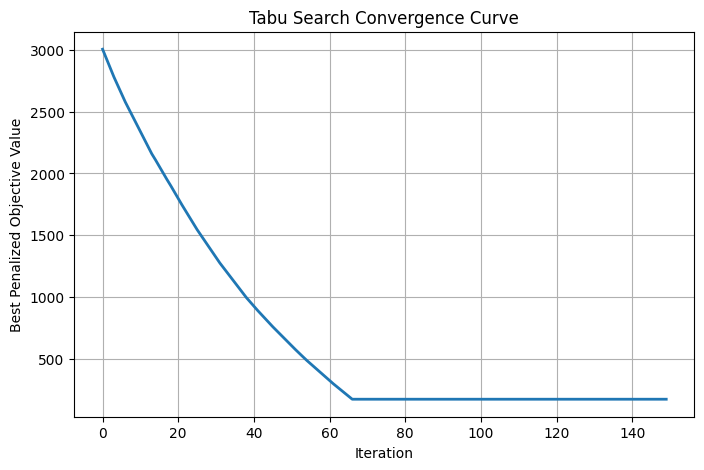

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(ts_result["convergence"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Penalized Objective Value")
plt.title("Tabu Search Convergence Curve")
plt.grid(True)
plt.show()

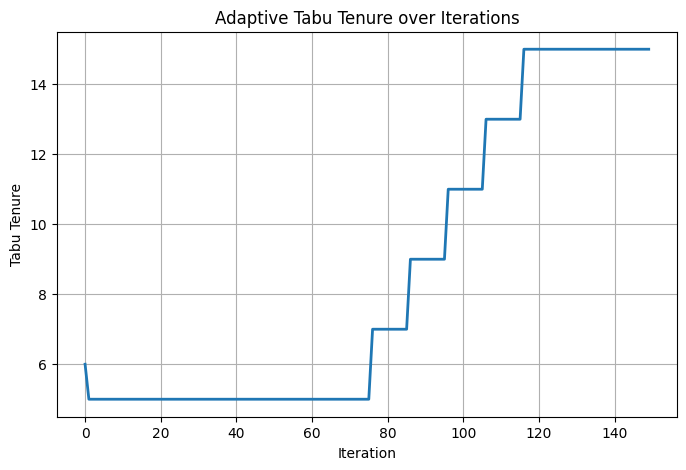

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(ts_result["tenure_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Tabu Tenure")
plt.title("Adaptive Tabu Tenure over Iterations")
plt.grid(True)
plt.show()